In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from scipy import constants
print(constants.liter)

import warnings
warnings.filterwarnings('ignore')


0.001


# **Part 1 Data Loading & Understanding**


In [3]:
df = pd.read_csv("data/games-features.csv")
df


,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,LegalNotice,Reviews,SupportedLanguages,Website,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,,,English French German Italian Spanish Simplifi...,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,,,English French German Italian Spanish,http://www.dayofdefeat.com/,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,,,English French German Korean,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13352,567660,567660,Baseball Riot,Baseball Riot,Jan 17 2017,0,0,1,0,0,...,Copyright (c) 2016 10tons Ltd.,,English**languages with full audio support,http://www.10tons.com/Game/baseball_riot.html,Minimum:OS: Windows XP / Vista / 7 / 8 / 10Pro...,,,,,
13353,567860,567860,Passage 4,Passage 4,Dec 13 2016,0,0,1,0,0,...,2016 copyright by netmin e.K.,,English* French Italian German* Spanish Dutch*...,http://www.libredia.com,Minimum:OS: Windows 2000/XP/Vista/7/8/10Proces...,,,,,
13354,567940,567940,Piximalism,Piximalism,Sep 26 2019,0,0,1,0,0,...,,,English,NaN,Minimum:OS: Microsoft(r) Windows(r) XP / Vista...,Recommended:OS: Microsoft(r) Windows(r) XP / V...,,,,
13355,568150,568150,Technoball,Technoball,Dec 12 2016,0,0,1,0,0,...,,,English**languages with full audio support,NaN,Minimum:OS: Windows 7 (64-bit)Processor: 2.5 G...,,,,,


In [4]:
df.shape

(13357, 78)

In [5]:
df.head()

,QueryID,ResponseID,QueryName,ResponseName,ReleaseDate,RequiredAge,DemoCount,DeveloperCount,DLCCount,Metacritic,...,LegalNotice,Reviews,SupportedLanguages,Website,PCMinReqsText,PCRecReqsText,LinuxMinReqsText,LinuxRecReqsText,MacMinReqsText,MacRecReqsText
0,10,10,Counter-Strike,Counter-Strike,Nov 1 2000,0,0,1,0,88,...,,,English French German Italian Spanish Simplifi...,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
1,20,20,Team Fortress Classic,Team Fortress Classic,Apr 1 1999,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
2,30,30,Day of Defeat,Day of Defeat,May 1 2003,0,0,1,0,79,...,,,English French German Italian Spanish,http://www.dayofdefeat.com/,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
3,40,40,Deathmatch Classic,Deathmatch Classic,Jun 1 2001,0,0,1,0,0,...,,,English French German Italian Spanish,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,
4,50,50,Half-Life: Opposing Force,Half-Life: Opposing Force,Nov 1 1999,0,0,1,0,0,...,,,English French German Korean,NaN,Minimum: 500 mhz processor 96mb ram 16mb video...,,Minimum: Linux Ubuntu 12.04 Dual-core from Int...,,Minimum: OS X Snow Leopard 10.6.3 1GB RAM 4GB...,


In [6]:
df.columns

Index(['QueryID', 'ResponseID', 'QueryName', 'ResponseName', 'ReleaseDate',
       'RequiredAge', 'DemoCount', 'DeveloperCount', 'DLCCount', 'Metacritic',
       'MovieCount', 'PackageCount', 'RecommendationCount', 'PublisherCount',
       'ScreenshotCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance',
       'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
       'AchievementCount', 'AchievementHighlightedCount', 'ControllerSupport',
       'IsFree', 'FreeVerAvail', 'PurchaseAvail', 'SubscriptionAvail',
       'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'PCReqsHaveMin',
       'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec',
       'MacReqsHaveMin', 'MacReqsHaveRec', 'CategorySinglePlayer',
       'CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO',
       'CategoryInAppPurchase', 'CategoryIncludeSrcSDK',
       'CategoryIncludeLevelEditor', 'CategoryVRSupport', 'GenreIsNonGame',
       'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual',
       'G

In [7]:
df.dtypes.value_counts()

bool       35
str        23
int64      18
float64     2
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13357 entries, 0 to 13356
Data columns (total 78 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   QueryID                      13357 non-null  int64  
 1   ResponseID                   13357 non-null  int64  
 2   QueryName                    13356 non-null  str    
 3   ResponseName                 13357 non-null  str    
 4   ReleaseDate                  13357 non-null  str    
 5   RequiredAge                  13357 non-null  int64  
 6   DemoCount                    13357 non-null  int64  
 7   DeveloperCount               13357 non-null  int64  
 8   DLCCount                     13357 non-null  int64  
 9   Metacritic                   13357 non-null  int64  
 10  MovieCount                   13357 non-null  int64  
 11  PackageCount                 13357 non-null  int64  
 12  RecommendationCount          13357 non-null  int64  
 13  PublisherCount             

# Part 2 Exploring Data Set


#### Basic Statistics

In [9]:
df[["Metacritic", "PriceFinal", "RequiredAge", "SteamSpyPlayersEstimate"]].describe()

,Metacritic,PriceFinal,RequiredAge,SteamSpyPlayersEstimate
count,13357.000000,13357.000000,13357.000000,1.335700e+04
mean,12.285319,8.798596,0.837688,1.081638e+05
std,27.510876,13.606061,3.625701,1.006635e+06
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,1.990000,0.000000,5.370000e+02
50%,0.000000,5.990000,0.000000,4.125000e+03
75%,0.000000,9.990000,0.000000,2.815800e+04
max,96.000000,449.990000,18.000000,9.068758e+07


#### Category Count

In [10]:
df["RequiredAge"].value_counts()

RequiredAge
0     12671
17      450
13       82
18       80
16       40
12       10
15        9
10        9
6         2
14        2
1         1
7         1
Name: count, dtype: int64

#### Genre: GenreIs* columns bata primary genre nikalne

In [11]:
genre_cols = [c for c in df.columns if c.startswith("GenreIs")]
def get_primary_genre(row):
    for col in genre_cols:
        if row[col]:
            return col.replace("GenreIs", "")
    return "Other"
    
df["Genre"] = df.apply(get_primary_genre, axis=1)
df["Genre"].value_counts()

Genre
Indie                   7780
Action                  1683
Adventure                849
Other                    743
Strategy                 671
Casual                   590
Simulation               351
NonGame                  319
RPG                      202
Racing                    78
Sports                    54
FreeToPlay                18
EarlyAccess               17
MassivelyMultiplayer       2
Name: count, dtype: int64

### Platform Breakdown

In [12]:
print("\nWindows:", df["PlatformWindows"].sum())
print("Linux:", df["PlatformLinux"].sum())
print("Mac:", df["PlatformMac"].sum())


Windows: 13355
Linux: 3057
Mac: 4562


#### Free vs Paid Games

In [13]:
print("\nFree Games:", df["IsFree"].sum())
print("\nPaid Games:", len(df) - df["IsFree"].sum())


Free Games: 1045

Paid Games: 12312


In [14]:
print("Free Games:", (df["IsFree"] == 1).sum()) # Bool ra int 2 otai ma kaam garcha
print("Paid Games:", (df["IsFree"] == 0).sum())

# Total check:
print("Total:", len(df))

Free Games: 1045
Paid Games: 12312
Total: 13357


#### Correlation Numeric only

In [15]:
print("\n---Top correlation with Metacritic---")
num_cols = ["Metacritic", "PriceFinal", "SteamSpyPlayersEstimate", "RecommendationCount",
             "AchievementCount", "DLCCount"]
print(df[num_cols].corr(numeric_only=True)["Metacritic"].round(3))


---Top correlation with Metacritic---
Metacritic                 1.000
PriceFinal                 0.178
SteamSpyPlayersEstimate    0.163
RecommendationCount        0.120
AchievementCount           0.133
DLCCount                   0.034
Name: Metacritic, dtype: float64


# **Part 3 Data Cleaning**

In [16]:
print("\nNull values before cleaning:") # counts null in ever columns
print(df.isnull().sum()[df.isnull().sum() > 0]) # filters to only show columns That have nulls


Null values before cleaning:
QueryName          1
SupportEmail       2
SupportURL         1
LegalNotice        1
Website         3161
dtype: int64


#### Review column Breakdown


In [17]:
print("=== REVIEWS COLUMN SUMMARY ===")
total = len(df)
has_review = (df['Reviews'].str.strip() != '').sum()
blank = (df['Reviews'].str.strip() == '').sum()

print(f"Total games       : {total}")
print(f"Has review text   : {has_review} ({has_review/total*100:.1f}%)")
print(f"Blank / empty     : {blank} ({blank/total*100:.1f}%)")


=== REVIEWS COLUMN SUMMARY ===
Total games       : 13357
Has review text   : 3314 (24.8%)
Blank / empty     : 10043 (75.2%)


#### Blank review check 


In [18]:
# df['Reviews_clean'] = df['Reviews'].str.strip()

# has_review = df['Reviews_clean'] != ''
# no_review = df['Reviews_clean'] == ''

# print("Has review:", has_review.sum())
# print("No review:", no_review.sum())

#### Sample - Review vaya ko games

In [19]:
# print("---Game Review Columns---")
# with_reviews = df[df['Reviews'].str.strip() != ''][['ResponseName', 'Reviews']].head(3)
# for _, row in with_reviews.iterrows():
#     print(f"\nGame: {row['ResponseName']}")
#     print(f"Review (first 150 chars): {row['Reviews'][:150]}")

#### Review blank vaya ko games

In [20]:
# print("\n--- 3 GAMES WITHOUT REVIEWS ---")
# with_reviews = df[df['Reviews'].str.strip() == ''][['ResponseName']].head(3)
# for _, row in with_reviews.iterrows():
#     print(f" - {row['ResponseName']}")

### 3.1 RelaseDate string to date time

In [21]:
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce')
print("\nReleaseDate dtype:", df['ReleaseDate'].dtype)


ReleaseDate dtype: datetime64[us]


### 3.2 ReleaseDate extract from releaseDate, fill missing with median


In [22]:
df['ReleaseYear'] = df['ReleaseDate'].dt.year
df['ReleaseYear'] = df['ReleaseYear'].fillna(df['ReleaseYear'].median())
df['ReleaseYear'] = df['ReleaseYear'].astype(int)
print("ReleaseYear nulls after fix:", df['ReleaseYear'].isnull().sum())

ReleaseYear nulls after fix: 0


In [23]:
df['ReleaseYear'].info()

<class 'pandas.Series'>
RangeIndex: 13357 entries, 0 to 13356
Series name: ReleaseYear
Non-Null Count  Dtype
--------------  -----
13357 non-null  int64
dtypes: int64(1)
memory usage: 104.5 KB


### 3.3 DiscountPct - calculate from price, fill 0 where no discount

In [24]:
df['DiscountPct'] = df.apply(
    lambda r: round((r['PriceInitial'] - r['PriceFinal']) / r['PriceInitial'], 4)
        if r['PriceInitial'] > 0 else 0.0,
    axis=1
)

print("DiscountPct Sample:", df['DiscountPct'].describe())

DiscountPct Sample: count    13357.000000
mean         0.024375
std          0.120901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.961900
Name: DiscountPct, dtype: float64


In [25]:
df['DiscountPct'].info()

<class 'pandas.Series'>
RangeIndex: 13357 entries, 0 to 13356
Series name: DiscountPct
Non-Null Count  Dtype  
--------------  -----  
13357 non-null  float64
dtypes: float64(1)
memory usage: 104.5 KB


### 3.4 Remove duplicate game names (keep first occurance)

In [26]:
before = len(df)
df = df.drop_duplicates(subset='ResponseName', keep='first')
print(f"\nDuplicates removed: {before - len(df)} rows")
print("Shape after dropping duplicates:", df.shape)


Duplicates removed: 158 rows
Shape after dropping duplicates: (13199, 81)


### Filtering invalid years ( keep 1990-2025 only)

In [27]:
df = df[df['ReleaseYear'].between(1990, 2025)]
print("Shape after year filter:", df.shape)

Shape after year filter: (13199, 81)


In [28]:
df['ReleaseYear'].info()

<class 'pandas.Series'>
Index: 13199 entries, 0 to 13356
Series name: ReleaseYear
Non-Null Count  Dtype
--------------  -----
13199 non-null  int64
dtypes: int64(1)
memory usage: 206.2 KB


# **4 Column Selection (78 -> 60)**

In [29]:
drop_cols = [
    'QueryID', 'ResponseID', 'QueryName', 'SupportEmail', 'SupportURL', 'Website', 'AboutText', 'ShortDescrip', 'DetailedDescrip',
    'DRMNotice', 'ExtUserAcctNotice', 'LegalNotice', 'Reviews', 'HeaderImage', 'Background',
    'PCMinReqsText', 'PCRecReqsText', 'LinuxMinReqsText', 'LinuxRecReqsText', 'MacMinReqsText', 'MacRecReqsText'
]

df = df.drop(columns=drop_cols)
print("Columns After drop:", df.shape[1])
print("Shape:", df.shape)
print("Columns kept:\n", df.columns)

Columns After drop: 60
Shape: (13199, 60)
Columns kept:
 Index(['ResponseName', 'ReleaseDate', 'RequiredAge', 'DemoCount',
       'DeveloperCount', 'DLCCount', 'Metacritic', 'MovieCount',
       'PackageCount', 'RecommendationCount', 'PublisherCount',
       'ScreenshotCount', 'SteamSpyOwners', 'SteamSpyOwnersVariance',
       'SteamSpyPlayersEstimate', 'SteamSpyPlayersVariance',
       'AchievementCount', 'AchievementHighlightedCount', 'ControllerSupport',
       'IsFree', 'FreeVerAvail', 'PurchaseAvail', 'SubscriptionAvail',
       'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'PCReqsHaveMin',
       'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec',
       'MacReqsHaveMin', 'MacReqsHaveRec', 'CategorySinglePlayer',
       'CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO',
       'CategoryInAppPurchase', 'CategoryIncludeSrcSDK',
       'CategoryIncludeLevelEditor', 'CategoryVRSupport', 'GenreIsNonGame',
       'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreI

# **5 Data Preparation**

**Release Month**

In [30]:
df['ReleaseMonth'] = df['ReleaseDate'].dt.month_name()

**Release Day of Week**

In [31]:
df['ReleaseDay'] = df['ReleaseDate'].dt.day_name()

**Release Decade**

In [32]:
df['ReleaseDecade'] = (df['ReleaseYear'] // 10 * 10).astype(str) + 's'

**Release Quarter**

In [33]:
df['ReleaseQuarter'] = 'Q' + df['ReleaseDate'].dt.quarter.astype(str)

In [34]:
print("Sample date parts:")
print(df[['ResponseName', 'ReleaseYear', 'ReleaseMonth', 'ReleaseDay',
           'ReleaseDecade', 'ReleaseQuarter']].head(5))

Sample date parts:
                ResponseName  ReleaseYear ReleaseMonth ReleaseDay  \
0             Counter-Strike         2000     November  Wednesday   
1      Team Fortress Classic         1999        April   Thursday   
2              Day of Defeat         2003          May   Thursday   
3         Deathmatch Classic         2001         June     Friday   
4  Half-Life: Opposing Force         1999     November     Monday   

  ReleaseDecade ReleaseQuarter  
0         2000s           Q4.0  
1         1990s           Q2.0  
2         2000s           Q2.0  
3         2000s           Q2.0  
4         1990s           Q4.0  


## Language Count - SupportedLanguages string bata count nikalne

In [35]:
df['LanguageCount'] = df['SupportedLanguages'].apply(
    lambda x: len([l for l in str(x).split(',') if l.strip()])
            if pd.notnull(x) else 0
)
print("\nLanguage count sample:")
print(df[['ResponseName', 'LanguageCount']].head(5))
print(df[['ResponseName', 'LanguageCount']].info())


Language count sample:
                ResponseName  LanguageCount
0             Counter-Strike              1
1      Team Fortress Classic              1
2              Day of Defeat              1
3         Deathmatch Classic              1
4  Half-Life: Opposing Force              1
<class 'pandas.DataFrame'>
Index: 13199 entries, 0 to 13356
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ResponseName   13199 non-null  str  
 1   LanguageCount  13199 non-null  int64
dtypes: int64(1), str(1)
memory usage: 309.4 KB
None


## Boolean columns -> int (PostgreSql import ko lagi)

In [36]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print("\nBool columns converted to int:", list(bool_cols))


Bool columns converted to int: ['ControllerSupport', 'IsFree', 'FreeVerAvail', 'PurchaseAvail', 'SubscriptionAvail', 'PlatformWindows', 'PlatformLinux', 'PlatformMac', 'PCReqsHaveMin', 'PCReqsHaveRec', 'LinuxReqsHaveMin', 'LinuxReqsHaveRec', 'MacReqsHaveMin', 'MacReqsHaveRec', 'CategorySinglePlayer', 'CategoryMultiplayer', 'CategoryCoop', 'CategoryMMO', 'CategoryInAppPurchase', 'CategoryIncludeSrcSDK', 'CategoryIncludeLevelEditor', 'CategoryVRSupport', 'GenreIsNonGame', 'GenreIsIndie', 'GenreIsAction', 'GenreIsAdventure', 'GenreIsCasual', 'GenreIsStrategy', 'GenreIsRPG', 'GenreIsSimulation', 'GenreIsEarlyAccess', 'GenreIsFreeToPlay', 'GenreIsSports', 'GenreIsRacing', 'GenreIsMassivelyMultiplayer']


# **6. Feature analysis**

**6.1 Age Rating**

In [37]:
def age_group(age):
    if age == 0:
        return 'All ages'
    elif age < 18:
        return 'Teen'
    else:
        return 'Mature'

df['AgeRating'] = df['RequiredAge'].apply(age_group)
print("AgeRating:\n", df['AgeRating'].value_counts())

AgeRating:
 AgeRating
All ages    12553
Teen          567
Mature         79
Name: count, dtype: int64


In [38]:
df['AgeRating'].info()

<class 'pandas.Series'>
Index: 13199 entries, 0 to 13356
Series name: AgeRating
Non-Null Count  Dtype
--------------  -----
13199 non-null  str  
dtypes: str(1)
memory usage: 206.2 KB


**6.2 Price Category**

In [39]:
def price_bucket(price):
    if price == 0:
        return 'Free'
    elif price <= 10:
        return 'Budget'
    elif price <=30:
        return 'Mid range'
    else:
        return 'Premium'

df['PriceCategory'] = df['PriceFinal'].apply(price_bucket)
print("\nPriceCategory:\n", df['PriceCategory'].value_counts())


PriceCategory:
 PriceCategory
Budget       7620
Free         2614
Mid range    2584
Premium       381
Name: count, dtype: int64


In [40]:
df['PriceCategory'].info()

<class 'pandas.Series'>
Index: 13199 entries, 0 to 13356
Series name: PriceCategory
Non-Null Count  Dtype
--------------  -----
13199 non-null  str  
dtypes: str(1)
memory usage: 206.2 KB


**6.3 Review Category**

In [41]:
def review_group(score):
    if score == 0:
        return 'Unrated'
    elif score < 50:
        return 'Poor'
    elif score < 70:
        return 'Average'
    elif score < 85:
        return 'Good'
    else: 
        return 'Excellent'

df['ReviewCategory'] = df['Metacritic'].apply(review_group)
print("\nReviewCategory:\n", df['ReviewCategory'].value_counts())


ReviewCategory:
 ReviewCategory
Unrated      11005
Good          1152
Average        722
Excellent      230
Poor            90
Name: count, dtype: int64


In [42]:
df['ReviewCategory'].info()

<class 'pandas.Series'>
Index: 13199 entries, 0 to 13356
Series name: ReviewCategory
Non-Null Count  Dtype
--------------  -----
13199 non-null  str  
dtypes: str(1)
memory usage: 206.2 KB


**6.4 Popularity Category in 4 groups**

In [43]:
df['PopularityCategory'] = pd.cut(
    df['SteamSpyPlayersEstimate'],
    bins=[0, 20000, 200000, 1000000, float('inf')],
    labels=['Small', 'Emerging', 'Popular', 'Blockbuster'],
    include_lowest=True
).astype(str)
print("\nPopularityCategory:\n", df['PopularityCategory'].value_counts())


PopularityCategory:
 PopularityCategory
Small          9435
Emerging       2698
Popular         802
Blockbuster     264
Name: count, dtype: int64


In [44]:
# def get_popularity(owners):
#     if owners < 20000:
#         return 'small'
#     elif owners < 200000:
#         return 'Emerging'
#     elif owners < 1000000:
#         return 'Popular'
#     else:
#         return 'Blockbuster'

# df['PopularityCategory'] = df['SteamSpyPlayersEstimate'].apply(get_popularity)
# print(df['PopularityCategory'].value_counts())

**6.5 Platform Category**

In [45]:
def platform_Cat(row):
    count = row['PlatformWindows'] + row['PlatformLinux'] + row['PlatformMac']
    if count == 3:
        return 'All Platforms'
    elif count == 2:
        return 'Two Platforms'
    elif row['PlatformWindows'] == 1:
        return 'Windows Only'
    else: 
        return 'Other'

df['PlatformCategory'] = df.apply(platform_Cat, axis=1)
print("\nPlatformCategory:\n", df['PlatformCategory'].value_counts())


PlatformCategory:
 PlatformCategory
Windows Only     8418
All Platforms    2781
Two Platforms    1998
Other               2
Name: count, dtype: int64


**6.6 Metacritic Category**

In [46]:
def metacritic_range(score):
    if score == 0:
        return 'Unrated'
    elif score < 50:
        return 'Low'
    elif score < 75:
        return 'Mid Range'
    else: 
        return 'High'
    
df['MetacriticCategory'] = df['Metacritic'].apply(metacritic_range)
print(df['MetacriticCategory'].value_counts())

MetacriticCategory
Unrated      11005
Mid Range     1110
High           994
Low             90
Name: count, dtype: int64


**6.7 IsFree Game category**

In [47]:
def free_or_paid(value):
    if value == 1:
        return 'Free'
    else:
        return 'Paid'
    
df['FreeOrPaid'] = df['IsFree'].apply(free_or_paid)

print(df['FreeOrPaid'].value_counts())

FreeOrPaid
Paid    12160
Free     1039
Name: count, dtype: int64


# **7 Data Manipulation**

In [48]:
print("\n---- Avg Price by Genre ----")
print(df.groupby('Genre')['PriceFinal'].mean().round(2).sort_values(ascending=False))


---- Avg Price by Genre ----
Genre
NonGame                 36.29
MassivelyMultiplayer    20.00
Sports                  19.23
Simulation              14.60
Racing                  13.06
Strategy                12.98
Action                  11.62
RPG                     11.18
Adventure                9.15
Indie                    6.96
Casual                   6.71
EarlyAccess              5.64
Other                    1.51
FreeToPlay               0.00
Name: PriceFinal, dtype: float64


In [49]:
print("\n--- Avg Metacritic by Genre ---")
print(df.groupby('Genre')['Metacritic'].mean().round(1).sort_values(ascending=False))


--- Avg Metacritic by Genre ---
Genre
Strategy                32.3
RPG                     28.0
Racing                  27.0
Action                  25.3
Sports                  13.8
Adventure               11.7
Simulation              10.2
Indie                    9.2
FreeToPlay               7.5
Casual                   3.9
Other                    0.7
EarlyAccess              0.0
MassivelyMultiplayer     0.0
NonGame                  0.0
Name: Metacritic, dtype: float64


In [50]:
print("\n--- Games Released Each Year ---")
print(df.groupby('ReleaseYear').size().sort_index())


--- Games Released Each Year ---
ReleaseYear
1997       1
1998       1
1999       2
2000       2
2001       4
2003       3
2004       6
2005       6
2006      63
2007     107
2008     177
2009     332
2010     292
2011     289
2012     388
2013     541
2014    1740
2015    3857
2016    5327
2017      60
2019       1
dtype: int64


In [51]:
print("\n--- Platform Totals ---")
print(df[['PlatformWindows', 'PlatformLinux', 'PlatformMac']].sum())


--- Platform Totals ---
PlatformWindows    13197
PlatformLinux       3038
PlatformMac         4524
dtype: int64


In [52]:
print("\n--- Top 10 by Recommendations ---")
print(df[['ResponseName', 'RecommendationCount']]
        .sort_values('RecommendationCount', ascending=False)
        .head(10).to_string(index=False)
      )


--- Top 10 by Recommendations ---
                    ResponseName  RecommendationCount
Counter-Strike: Global Offensive              1427633
                          Dota 2               590480
                 Team Fortress 2               383949
                      Garrys Mod               237684
                        Unturned               222301
                        PAYDAY 2               219763
     The Elder Scrolls V: Skyrim               182587
                            DayZ               153350
                            Rust               145688
                   Left 4 Dead 2               140726


# **8. Vizulization (Python Preview)**

In [53]:
# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# fig.suptitle('Games Dataset - EDA Visualizations', fontsize=14, fontweight='bold')

# # Plot 1 — Line Chart (ReleaseYear)
# year_counts = df['ReleaseYear'].value_counts().sort_index().reset_index()
# year_counts.columns = ['ReleaseYear', 'Count']
# sns.lineplot(data=year_counts, x='ReleaseYear', y='Count',
#              color='steelblue', linewidth=2, ax=axes[0, 0])
# axes[0, 0].set_title('Games Released Per Year')

# # Plot 2 — Bar Chart (AgeRating)
# sns.countplot(data=df, x='AgeRating', palette='Set2', ax=axes[0, 1])
# axes[0, 1].set_title('Age Rating Distribution')

# # Plot 3 — Horizontal Bar (PriceCategory)
# sns.countplot(data=df, y='PriceCategory', palette='Blues_r', ax=axes[1, 0])
# axes[1, 0].set_title('Price Category')

# # Plot 4 — Bar Chart (PopularityCategory)
# pop_order = ['Small', 'Emerging', 'Popular', 'Blockbuster']
# sns.countplot(data=df, x='PopularityCategory', order=pop_order,
#               palette='rocket_r', ax=axes[1, 1])
# axes[1, 1].set_title('Popularity Category')

# plt.tight_layout()
# plt.show()

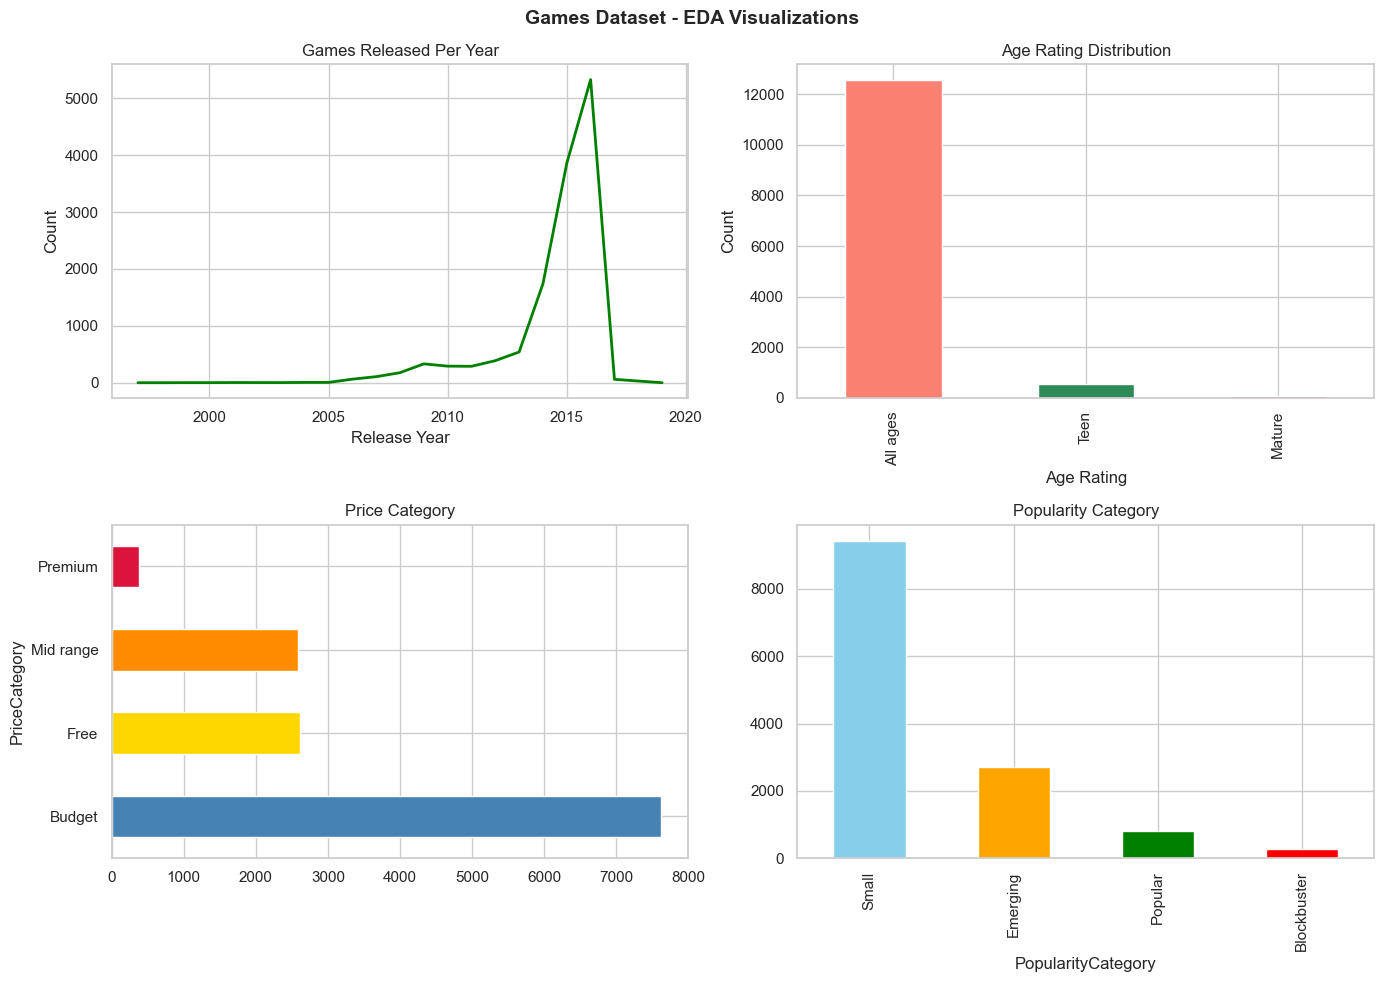

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Games Dataset - EDA Visualizations', fontsize=14, fontweight='bold')

# Plot 1 — Line Chart (ReleaseYear)
df['ReleaseYear'].value_counts().sort_index().plot(
    kind='line',
    ax=axes[0,0],
    color='green',
    linewidth=2,
)
axes[0,0].set_title('Games Released Per Year')
axes[0,0].set_xlabel('Release Year')
axes[0,0].set_ylabel('Count')

# Plot 2 — Bar Chart (AgeRating)
df["AgeRating"].value_counts().plot(
    kind="bar",
    ax=axes[0,1],
    color=["salmon", "seagreen", "crimson"]
)
axes[0,1].set_title("Age Rating Distribution")
axes[0,1].set_xlabel("Age Rating")
axes[0,1].set_ylabel('Count')

# Plot 3 Horizontal Bar graph (Price Category)
df["PriceCategory"].value_counts().plot(
    kind="barh",
    ax=axes[1,0],
    color=["steelblue", "gold", "darkorange", "crimson"]
)
axes[1,0].set_title("Price Category")

# Plot 4 Bar chart (Popularity Category)
df["PopularityCategory"].value_counts().reindex(
    ["Small", "Emerging", "Popular", "Blockbuster"]
).plot(
    kind="bar",
    ax=axes[1,1],
    color=["skyblue", "orange", "green", "red"]
)
axes[1,1].set_title("Popularity Category")

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Free & Paid Games')

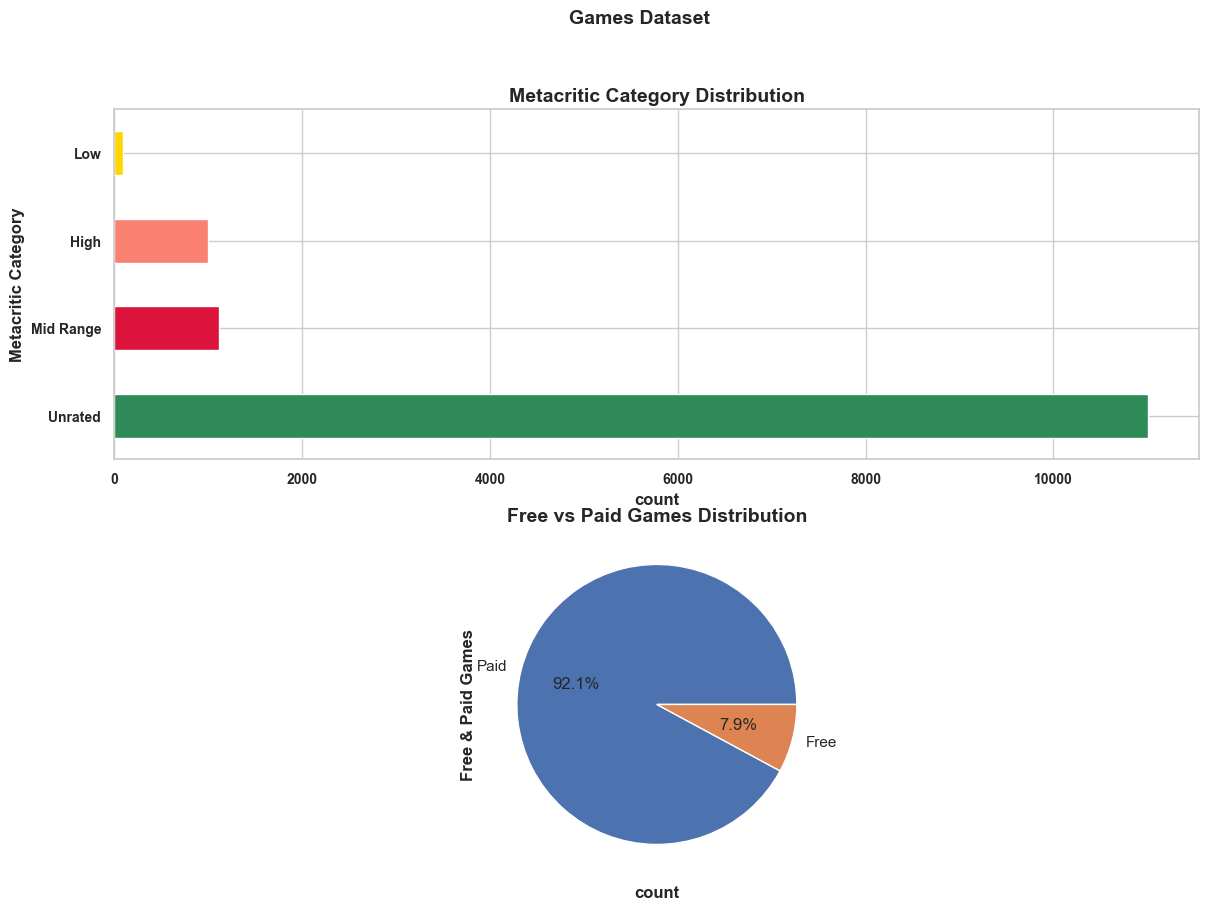

In [55]:
fig, axes = plt.subplots(2, figsize=(14,10))
fig.suptitle("Games Dataset", fontsize=14, fontweight="bold")

# Plot1: Price Distribution
df["MetacriticCategory"].value_counts().plot(
          kind="barh",
          ax=axes[0],
          color=["seagreen", "crimson", "salmon", "gold"]
            #    color=[""]                
)
axes[0].set_title("Metacritic Category Distribution",
                  fontweight="bold",
                  fontsize=14
)
axes[0].set_xlabel(
    "count",
    fontweight="bold"
)
axes[0].set_ylabel(
    "Metacritic Category",
    fontweight="bold"
)

for label in axes[0].get_xticklabels():
    label.set_fontweight("bold")
    label.set_fontsize("10")

for label in axes[0].get_yticklabels():
    label.set_fontweight("bold")
    label.set_fontsize("10")

# Plot2 Free vs Paid Games

df["FreeOrPaid"].value_counts().plot(
          kind="pie",
          ax=axes[1],
          color=["darkorange", "steelblue"],
          autopct='%1.1f%%'           
)
axes[1].set_title("Free vs Paid Games Distribution",
                  fontweight="bold",
                  fontsize=14
)
axes[1].set_xlabel(
    "count",
    fontweight="bold"
)
axes[1].set_ylabel(
    "Free & Paid Games",
    fontweight="bold"
)



#### Histograms [PriceFinal, Metacritic, ReleaseYear]

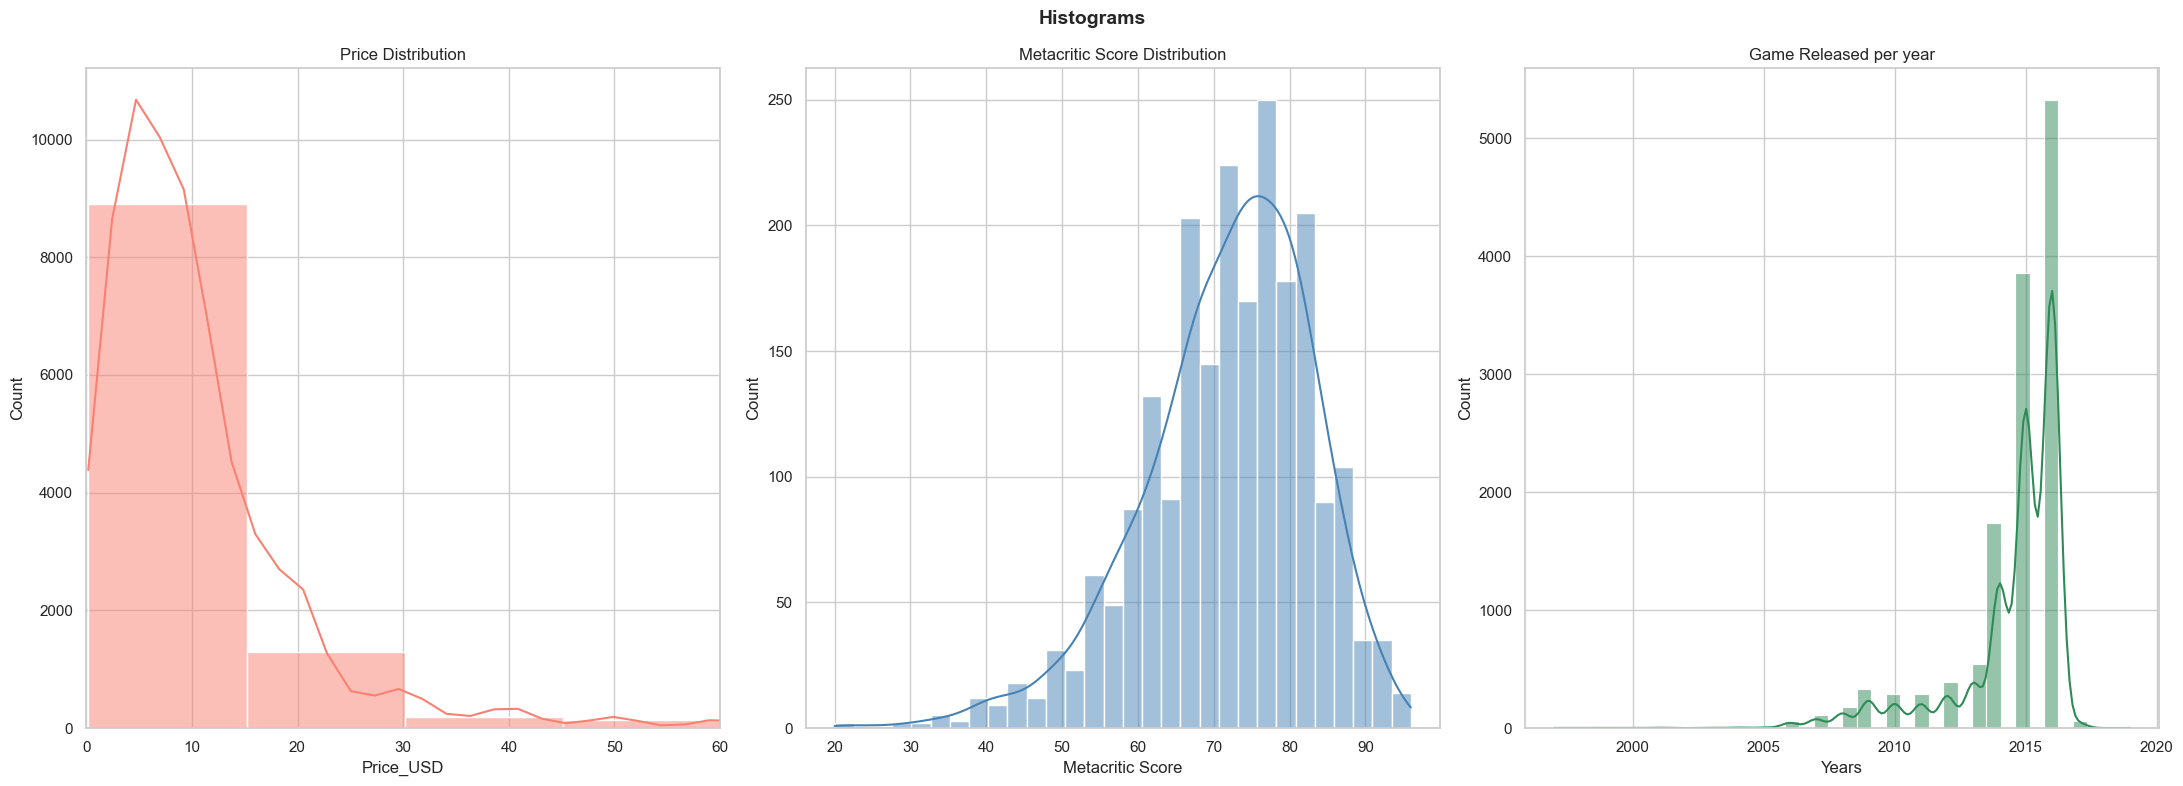

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Histograms', fontsize=14, fontweight='bold')

# Histogram 1: Price (Paid Games only)

paid_df = df[df['PriceFinal'] > 0]
sns.histplot(data=paid_df, x='PriceFinal', bins=30, color='salmon',
             kde=True, ax=axes[0])
axes[0].set_xlim(0, 60)
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price_USD')

# Histogram 2: Metacritic (rated games only)

rated_df = df[df['Metacritic'] > 0]
sns.histplot(data=rated_df, x='Metacritic', bins=30, color='steelblue',
             kde=True, ax=axes[1])
axes[1].set_title('Metacritic Score Distribution')
axes[1].set_xlabel('Metacritic Score')

#  Histogram 3: Game Released Years

rec_df = df[df['ReleaseYear'] > 0]
sns.histplot(data=rec_df, x='ReleaseYear', bins=40,
             color='seagreen', kde=True, ax=axes[2])
axes[2].set_title('Game Released per year')
axes[2].set_xlabel('Years')


plt.tight_layout()
plt.show()

#### ControllerSupport Pie Chart

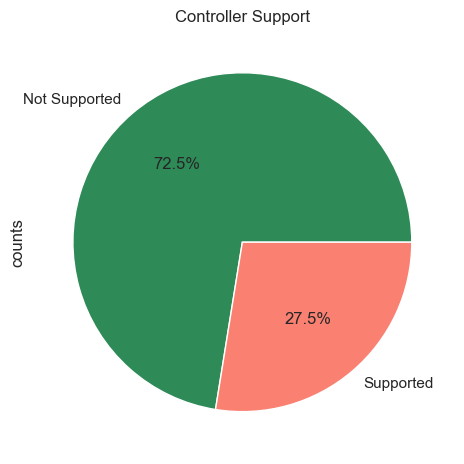

In [57]:
ctrl_counts = df['ControllerSupport'].map({1: 'Supported', 0: 'Not Supported'}).value_counts()

ctrl_counts.plot(
    kind='pie',
    labels=ctrl_counts.index,
    colors=['seagreen', 'salmon'],
    autopct='%1.1f%%',
    ylabel='counts',
    title='Controller Support'
)

plt.tight_layout()
plt.show()

#### Scatter plot PriceFinal vs Metacritic 

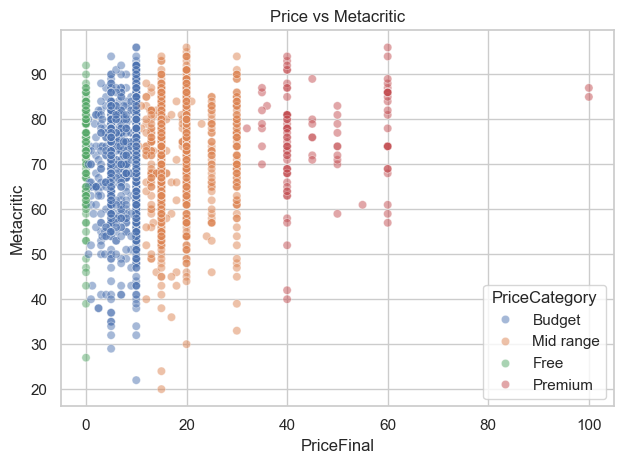

In [58]:
score_df = df[df['Metacritic'] > 0 & (df['PriceFinal'] <=60)]

sns.scatterplot(data=score_df, x='PriceFinal', y='Metacritic',
                hue='PriceCategory', alpha=0.5).set_title('Price vs Metacritic')

plt.tight_layout()
plt.show()

#### Boxplot Metacritic by Genre

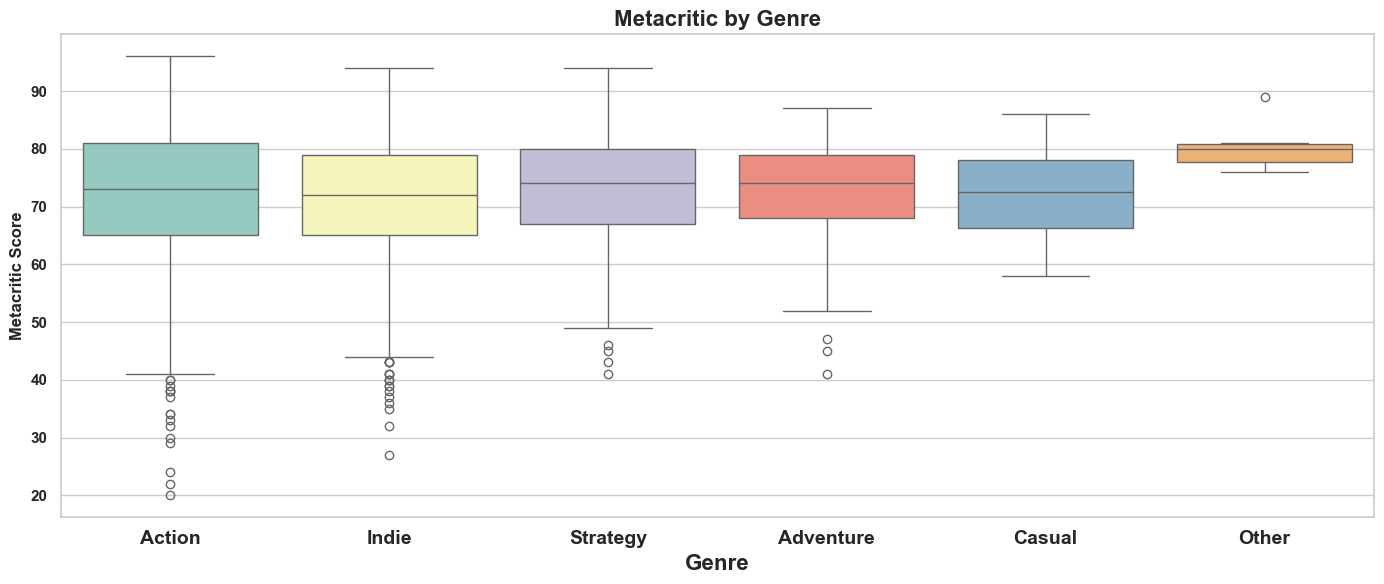

In [59]:
plt.figure(figsize=(14,6))

top6_genres = df['Genre'].value_counts().head(6).index.tolist()

genre_df = df[(df['Metacritic'] > 0) & (df['Genre'].isin(top6_genres))]

sns.boxplot(
    data=genre_df,
    x='Genre',
    y='Metacritic',
    palette='Set3'
)

plt.title('Metacritic by Genre', fontweight='bold', fontsize=16)
plt.xlabel('Genre', fontweight='bold', fontsize=16)
plt.ylabel('Metacritic Score', fontweight='bold')

plt.xticks(rotation=0, fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold')

plt.tight_layout()
plt.show()

#### Heat map Numerical columns correlation

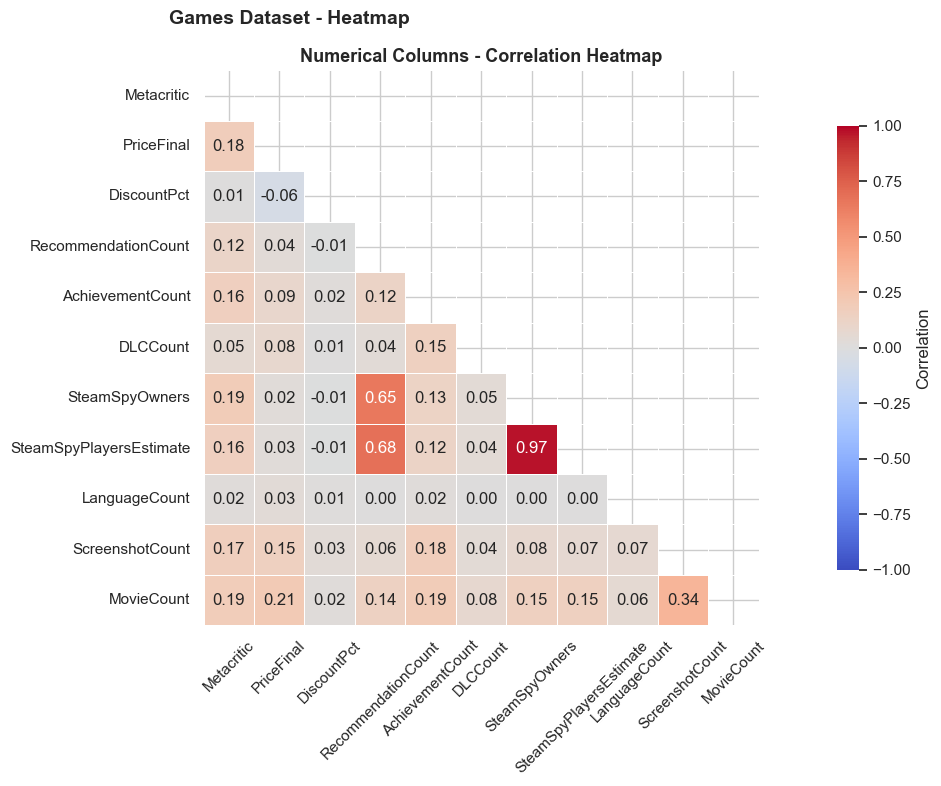

In [60]:
fig, axes = plt.subplots(1, 1, figsize=(16, 8))

num_cols = ["Metacritic", "PriceFinal", "DiscountPct", "RecommendationCount", "AchievementCount", "DLCCount",
            "SteamSpyOwners", "SteamSpyPlayersEstimate",
            "LanguageCount", "ScreenshotCount", "MovieCount"]

corr = df[num_cols].corr()

# Upper triangle (Optional remove for full matrix)

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot= True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlation', 'shrink': 0.8},
    ax=axes
)

axes.set_title('Numerical Columns - Correlation Heatmap',
               fontweight='bold', fontsize=13)
axes.tick_params(axis='x', rotation=45)
axes.tick_params(axis='y', rotation=0)

fig.suptitle('Games Dataset - Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Violin Plot [Price Category vs Metacritic]

**The Violin plot compares the distribution of Metacritic scores across different price categories (Free, Budget, Mid Range, Premium). The `price_order` parameter is used only to control the order of categroies displayed on the x-axis** 

In [61]:
print(df['PriceCategory'].unique())

<StringArray>
['Budget', 'Mid range', 'Free', 'Premium']
Length: 4, dtype: str


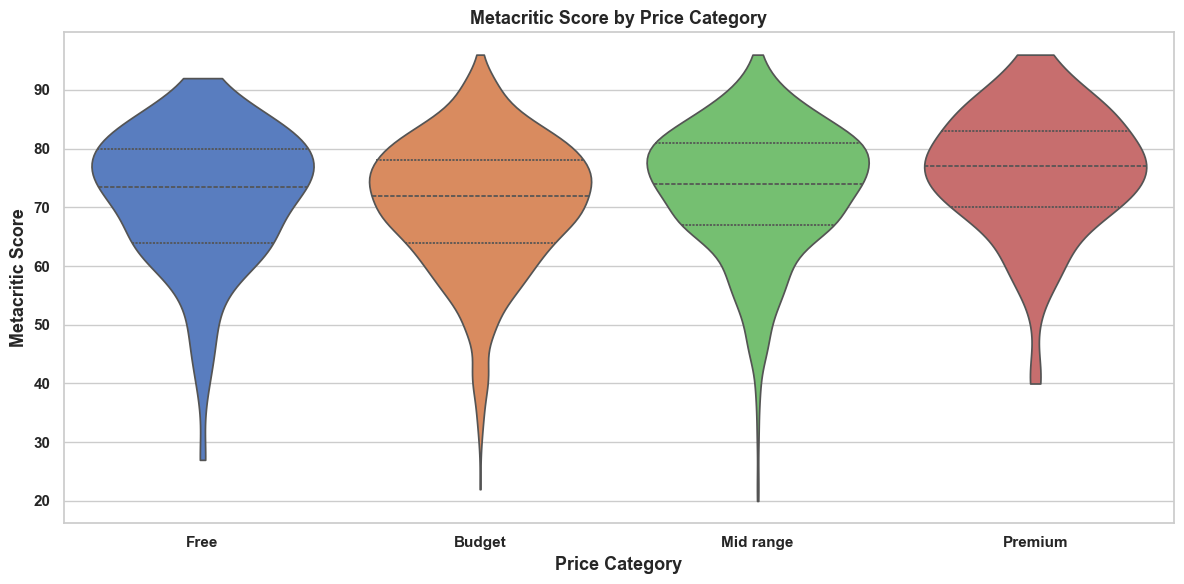

In [62]:
plt.figure(figsize=(12, 6))

score = df[df['Metacritic'] > 0]
price_order = ['Free', 'Budget', 'Mid range', 'Premium']
sns.violinplot(
    data=score,
    x='PriceCategory',
    y='Metacritic',
    order=price_order,
    palette='muted',
    inner='quartile', # Quartile lines inside violin
    cut=0
)
plt.title('Metacritic Score by Price Category', fontweight='bold', fontsize=13)
plt.xlabel('Price Category', fontweight='bold', fontsize=13)
plt.ylabel('Metacritic Score', fontweight='bold', fontsize=13)
plt.xticks(fontweight='bold', fontsize=11)
plt.yticks(fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

##### Genre vs Metacritic Violin plot

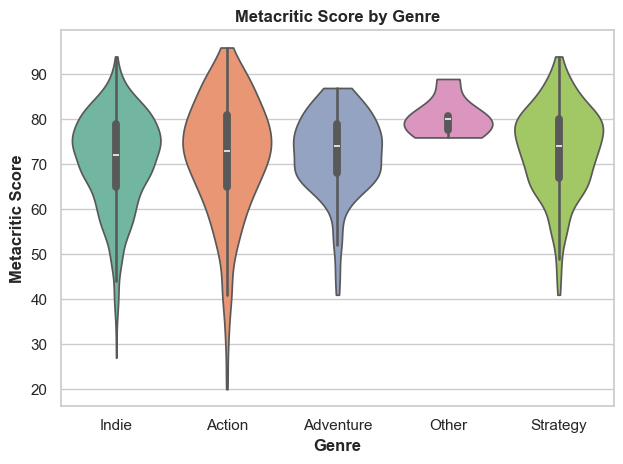

In [63]:
top5 = df['Genre'].value_counts().head(5).index.tolist()
rated_genre = df[(df['Metacritic'] > 0) & (df['Genre'].isin(top5))]
sns.violinplot(
    data=rated_genre,
    x='Genre', y='Metacritic',
    order=top5,
    palette='Set2',
    inner='box',
    cut=0,
)
plt.title('Metacritic Score by Genre', fontweight='bold')
plt.xlabel('Genre', fontweight='bold')
plt.ylabel('Metacritic Score', fontweight='bold')
plt.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

#### KDE plot Metacritic by reviewCategory

In [64]:
print(df['ReviewCategory'].unique())

<StringArray>
['Excellent', 'Unrated', 'Good', 'Average', 'Poor']
Length: 5, dtype: str


In [65]:
df['ReviewCategory'].value_counts()

ReviewCategory
Unrated      11005
Good          1152
Average        722
Excellent      230
Poor            90
Name: count, dtype: int64

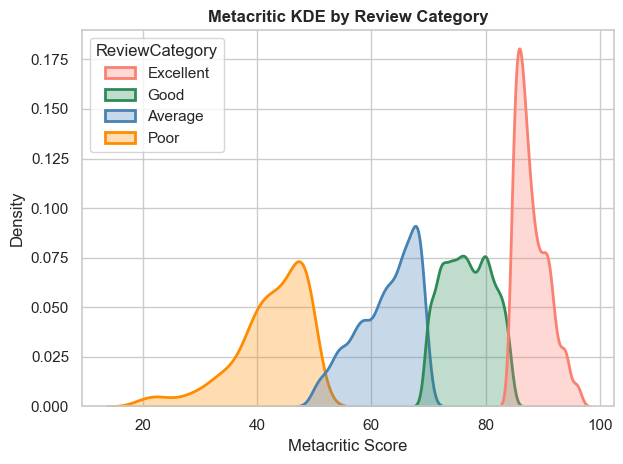

In [70]:
plt.Figure(figsize=(12, 6))

rated = df[df['Metacritic'] > 0]

palette_map = {'Excellent': 'salmon', 'Good':'seagreen',
               'Average': 'steelblue', 'Poor':'darkorange'}

sns.kdeplot(
    data=rated,
    x='Metacritic',
    hue='ReviewCategory',
    fill=True, alpha=0.3,
    linewidth=2,
    bw_adjust=0.8,
    common_norm=False,    # normalize each group independently
    palette=palette_map,
)
plt.title('Metacritic KDE by Review Category', fontweight='bold')
plt.xlabel('Metacritic Score')
plt.tight_layout()
plt.show()

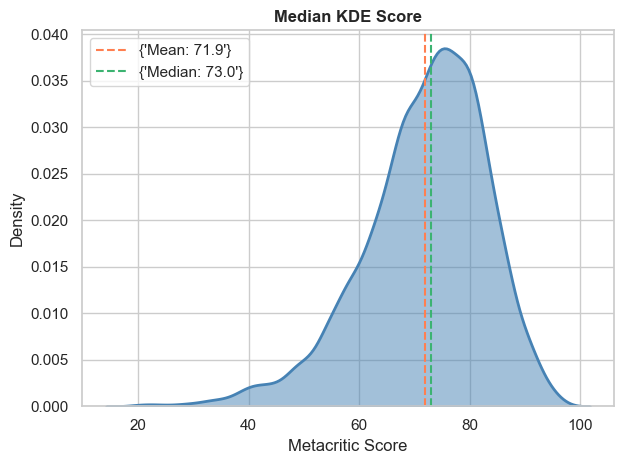

In [71]:
plt.Figure(figsize=(12, 6))

rated = df[df['Metacritic'] > 0]

sns.kdeplot(
    data=rated,
    x='Metacritic',
    fill=True, alpha=0.5,
    color='steelblue',
    linewidth=2,
    bw_adjust=0.8
)
plt.axvline(rated['Metacritic'].mean(), color='coral', linestyle='--',linewidth=1.5, label= {f'Mean: {rated['Metacritic'].mean():.1f}'})
plt.axvline(rated['Metacritic'].median(), color='mediumseagreen', linestyle='--', linewidth=1.5, label= {f'Median: {rated['Metacritic'].median():.1f}'})

plt.title('Median KDE Score', fontweight='bold')
plt.xlabel('Metacritic Score')
plt.legend()
plt.tight_layout()
plt.show()